# EDA of items_human.parquet

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
file_path = "../data/items_human.parquet"
df = pl.read_parquet(file_path)
df.head()

id,name,attributes,category
i64,str,str,str
197,"""victor reinz прокладка впускно…","""{""артикул"":""703315700"",""бренд""…","""Автотовары"""
415,"""stellox диск тормозной, арт. 8…","""{""артикул"":""stellox_8500892sx""…","""Автотовары"""
427,"""комплект подшипника ступицы ко…","""{""артикул производителя"":"""",""б…","""Автотовары"""
1027,"""kraft подшипник ступицы, арт. …","""{""артикул"":""112097-01"",""бренд""…","""Автотовары"""
2639,"""фильтр салонный skoda fabia 00…","""{""альтернативные артикулы това…","""Автотовары"""


In [3]:
print(f"   Строк: {df.height:,}")
print(f"   Колонок: {df.width}")
schema_dict = dict(df.schema)
for i, (col, dtype) in enumerate(schema_dict.items()):
    print(f"   {col}: {dtype}")

   Строк: 711,304
   Колонок: 4
   id: Int64
   name: String
   attributes: String
   category: String


In [4]:
null_counts = df.select(pl.all().is_null().sum())
cols = null_counts.columns
values = null_counts.row(0) 

cols_with_nulls = {
    col: count for col, count in zip(cols, values) if count > 0
}

print(f"Колонок с пропусками: {len(cols_with_nulls)}")

Колонок с пропусками: 0


In [11]:
category_stats = df.group_by("category").count()

category_stats = category_stats.sort("count", descending=True)

category_pd = category_stats.to_pandas()

C:\Users\iVAN\AppData\Local\Temp\ipykernel_17576\3377786624.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  category_stats = df.group_by("category").count()


C:\Users\iVAN\AppData\Local\Temp\ipykernel_17576\2121412819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_pd, x="count", y="category", palette="viridis")


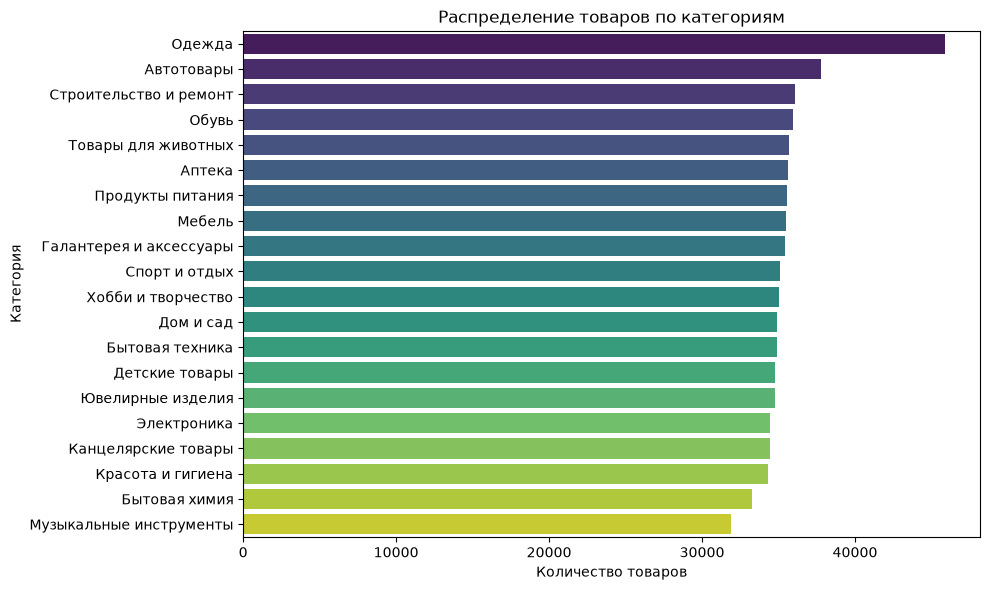

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(data=category_pd, x="count", y="category", palette="viridis")

plt.title("Распределение товаров по категориям")
plt.xlabel("Количество товаров")
plt.ylabel("Категория")
plt.tight_layout()
plt.show()